In [320]:
# Created a conda environment 
# conda install -c conda-forge swig box2d-py
# Python version 3.10.18

In [321]:
#! pip install gymnasium[box2d]
#! pip install pygame
#! pip install tqdm
#! pip install seaborn
#! pip install matplotlib
#! pip install "numpy<2.0"
#! pip install torch

In [322]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import deque
import os
from torch.distributions import Normal
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [323]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [324]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [325]:
ENV =  gym.make("LunarLander-v3", continuous=True, gravity=-10.0,
               enable_wind=True, wind_power=15.0, turbulence_power=1.5, render_mode="rgb_array")

In [326]:
print("Observation space ", ENV.observation_space)

Observation space  Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [327]:
print("Action Space Shape", ENV.action_space)

Action Space Shape Box(-1.0, 1.0, (2,), float32)


In [328]:
ENV.reset(seed=SEED)
ENV.action_space.seed(SEED)
ENV.observation_space.seed(SEED)

42

In [329]:
obs_dim = ENV.observation_space.shape[0]
act_dim = ENV.action_space.shape[0]
act_limit = float(ENV.action_space.high[0])


In [330]:
# Define the Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(ActorCritic, self).__init__()
        # Shared layers
        self.base = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Actor head
        self.mu_head = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))  # learnable log_std
        # Critic head
        self.value_head = nn.Linear(hidden_dim, 1)

        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0)

    def forward(self, state):
        x = self.base(state)
        mu = torch.tanh(self.mu_head(x))
        std = torch.exp(self.log_std)
        value = self.value_head(x)
        return mu, std, value

    def get_action(self, state):
        mu, std, _ = self.forward(state)
        dist = Normal(mu, std)
        action = dist.sample()
        return (
            action.detach().cpu().numpy().astype(np.float32).flatten(),
            dist.log_prob(action).sum(dim=-1)
        )

    def evaluate(self, state, action):
        mu, std, value = self.forward(state)
        dist =  Normal(mu, std)
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_prob, entropy, value.squeeze(-1)

In [331]:
# Define the PPO agent
class PPOAgent:
    def __init__(self, env, gamma=0.99, clip_eps=0.02, lam=0.95, epochs=5, batch_size=64, lr=1e-4):
        self.env = env
        self.gamma = gamma
        self.clip_eps = clip_eps
        self.lam = lam
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.entropy_coef = 0.02
        self.lr = lr
        self.model = ActorCritic(env.observation_space.shape[0], env.action_space.shape[0]).to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=lr)

    def compute_gae(self, rewards, values, dones):
        gae = 0
        returns = []
        values = values + [0]  # bootstrap value
        for step in reversed(range(len(rewards))):
            delta = rewards[step] + self.gamma * values[step + 1] * (1 - dones[step]) - values[step]
            gae = delta + self.gamma * self.lam * (1 - dones[step]) * gae
            returns.insert(0, gae + values[step])
        return returns

    def update(self, states, actions, old_log_probs, returns, advantages):
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.FloatTensor(actions).to(self.device)
        old_log_probs = torch.FloatTensor(old_log_probs).to(self.device)
        returns = torch.FloatTensor(returns).to(self.device)
        advantages = torch.FloatTensor(advantages).to(self.device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(self.epochs):
            indices = np.arange(len(states))
            np.random.shuffle(indices)
            for i in range(0, len(states), self.batch_size):
                idx = indices[i:i+self.batch_size]
                log_probs, entropy, values = self.model.evaluate(states[idx], actions[idx])
                ratio = torch.exp(log_probs - old_log_probs[idx])
                surr1 = ratio * advantages[idx]
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages[idx]
                entropy_bonus = 0.01 * entropy.mean()
                actor_loss = -torch.min(surr1, surr2).mean() - entropy_bonus
                critic_loss = (returns[idx] - values).pow(2).mean()
                loss = actor_loss + 0.5 * critic_loss - self.entropy_coef * entropy.mean()

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
                self.optimizer.step()

    def train(self, total_timesteps=200000, rollout_steps=8192, ppo_epochs=4, batch_size=64):
        state, _ = self.env.reset(seed=SEED)
        reward_history = []
        step_log = []
        step_rewards = []
        total_steps = 0
        episode_reward = 0
        rollout_buffer = []

        while total_steps < total_timesteps:
            for _ in range(rollout_steps):
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    action, log_prob = self.model.get_action(state_tensor)
                    _, _, value = self.model(state_tensor)

                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                # Store step-level reward
                step_rewards.append((total_steps + 1, reward))

                rollout_buffer.append((state, action, log_prob.item(), reward, done, value.item()))
                state = next_state
                episode_reward += reward
                total_steps += 1

                if done:
                    reward_history.append(episode_reward)
                    step_log.append(total_steps)
                    episode_reward = 0
                    state, _ = self.env.reset()

            # Training Phase
            states, actions, log_probs, rewards_, dones_, values_ = zip(*rollout_buffer)
            returns = self.compute_gae(rewards_, list(values_), dones_)
            advantages = torch.tensor(returns) - torch.tensor(values_)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            states_tensor = torch.tensor(states, dtype=torch.float32)
            actions_tensor = torch.tensor(actions, dtype=torch.float32)
            old_log_probs_tensor = torch.tensor(log_probs, dtype=torch.float32)
            returns_tensor = torch.tensor(returns, dtype=torch.float32)
            values_tensor = torch.tensor(values_, dtype=torch.float32)
            advantages_tensor = advantages.float()

            dataset = TensorDataset(states_tensor, actions_tensor, old_log_probs_tensor,
                                returns_tensor, values_tensor, advantages_tensor)
            loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


            for _ in range(ppo_epochs):
                for batch in loader:
                    states_b, actions_b, log_probs_old_b, returns_b, values_b, adv_b = [x.to(self.device) for x in batch]
                    log_probs, entropy, new_values = self.model.evaluate(states_b, actions_b)

                    # === PPO surrogate objective ===
                    ratio = torch.exp(log_probs - log_probs_old_b)
                    surr1 = ratio * adv_b
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_b
                    actor_loss = -torch.min(surr1, surr2).mean()

                    # === Value function clipping ===
                    value_clipped = values_b + (new_values - values_b).clamp(-self.clip_eps, self.clip_eps)
                    vf_loss1 = (new_values - returns_b).pow(2)
                    vf_loss2 = (value_clipped - returns_b).pow(2)
                    critic_loss = torch.max(vf_loss1, vf_loss2).mean()

                    # === Total loss ===
                    loss = actor_loss + 0.5 * critic_loss - self.entropy_coef * entropy.mean()

                    self.optimizer.zero_grad()
                    loss.backward()

                    # === Clip gradients ===
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)

                    self.optimizer.step()


            rollout_buffer.clear()

            # === Learning rate annealing ===
            frac = 1.0 - (total_steps / total_timesteps)
            lr_now = self.lr * frac
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr_now

            # Logs
            if total_steps % 2000 == 0:
                avg_reward = np.mean(reward_history[-100:]) if len(reward_history) >= 100 else np.mean(reward_history)
                print(f"Step {total_steps}, Avg Reward (last 100): {avg_reward:.2f}")

        torch.save(self.model.state_dict(), "ppo_lunarlander_final.pt")
        return reward_history, step_log, step_rewards
    
    # === Evaluation Function ===
    def evaluate(self, episodes=3):
        test_env = gym.make("LunarLander-v3", continuous=True, render_mode="human")
        for ep in range(episodes):
            obs, _ = test_env.reset()
            obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
            test_env.action_space.seed(SEED)
            total_reward = 0
            for _ in range(1000):
                with torch.no_grad():
                    action, _ = self.model.get_action(torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device))
                obs, r, term, trunc, _ = test_env.step(action.flatten())
                total_reward += r
                if term or trunc:
                    break
            print(f"Eval Episode {ep+1}: Total Reward = {total_reward:.1f}")
        test_env.close()

    def plot_rewards(self, reward_history, step_log, step_rewards):
        plt.figure(figsize=(10, 5))
        plt.plot(step_log, reward_history, alpha=0.3, label="Raw reward")

        if len(reward_history) >= 100:
            smoothed = np.convolve(reward_history, np.ones(100) / 100, mode='valid')
            plt.plot(step_log[99:], smoothed, label="100-ep moving avg", color='red')

        plt.axhline(200, linestyle="--", color="green", label="Solved")
        plt.xlabel("Steps")
        plt.ylabel("Total Reward")
        plt.title("PPO on LunarLander-v3")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("ppo_lunarlander_final.png")
        plt.show()

        # === Rolling Std Dev (last 50,000 steps) ===
        if len(reward_history) >= 100:
            window = 100  # window size for std dev
            recent_indices = [i for i, s in enumerate(step_log) if s >= step_log[-1] - 50000]

            rolling_std = [
                np.std(reward_history[i - window:i])
                for i in recent_indices if i >= window
            ]

            recent_steps = [step_log[i] for i in recent_indices if i >= window]

            plt.figure(figsize=(10, 4))
            plt.plot(recent_steps, rolling_std)
            plt.xlabel("Steps")
            plt.ylabel("Std Dev")
            plt.title("Rolling Std Dev of Reward (Window = 100, Last 50,000 Steps)")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("ppo_lunarlander_stddev.png")
            plt.show()


In [332]:
agent = PPOAgent(ENV, clip_eps=0.1, lr=1e-4)
agent.model.to(device)

ActorCritic(
  (base): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=256, out_features=2, bias=True)
  (value_head): Linear(in_features=256, out_features=1, bias=True)
)

In [ ]:
reward_history, step_log, step_rewards = agent.train(300000)

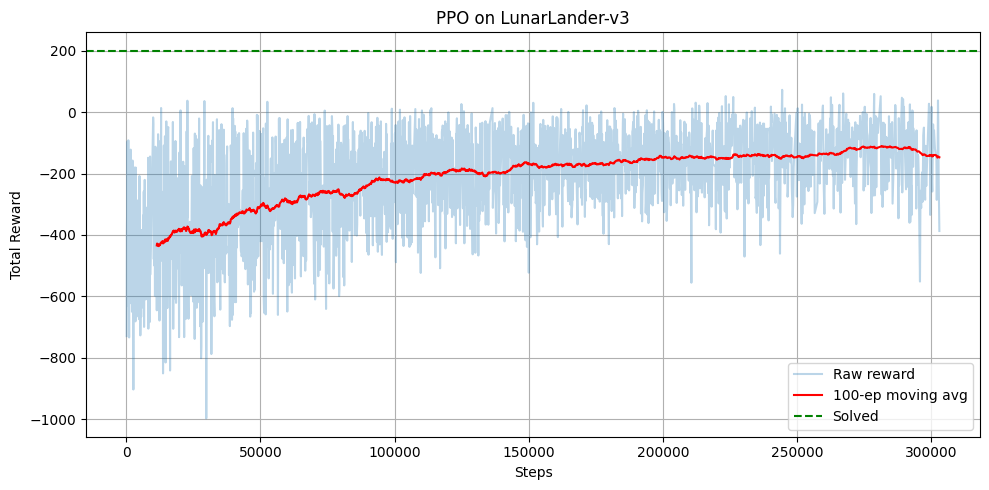

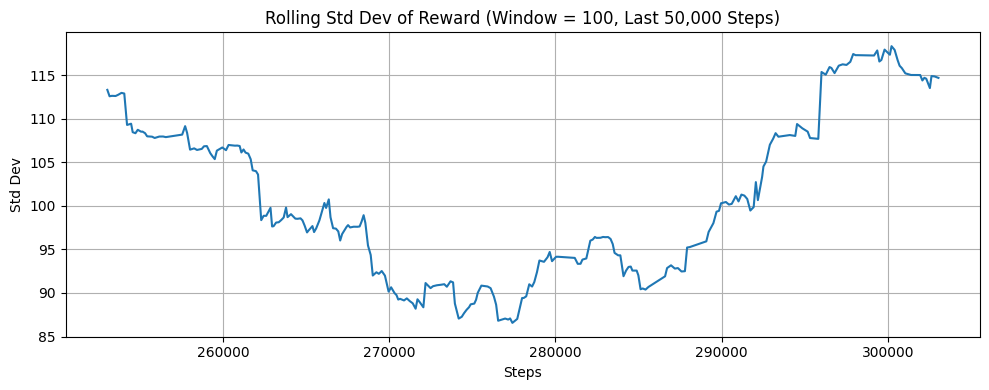

In [337]:
agent.plot_rewards(reward_history, step_log, step_rewards)

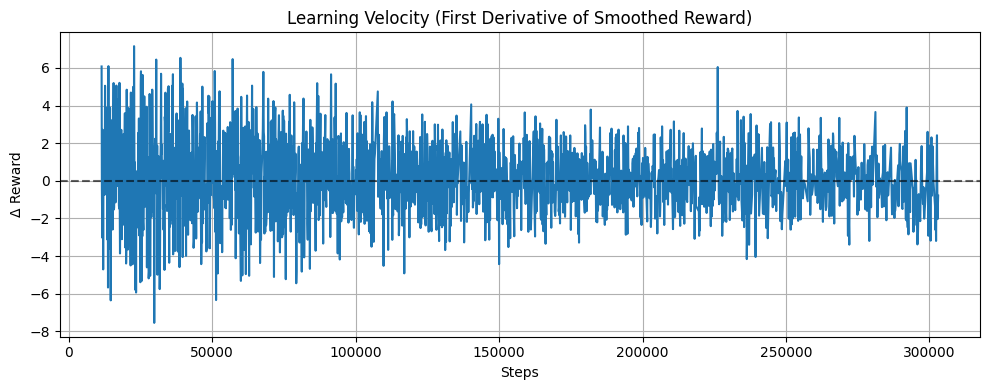

In [334]:
def plot_learning_velocity(step_log, reward_history, window=100):
    smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')
    velocity = np.diff(smoothed)

    plt.figure(figsize=(10, 4))
    plt.plot(step_log[window:window+len(velocity)], velocity)
    plt.axhline(0, linestyle='--', color='black', alpha=0.6)
    plt.title("Learning Velocity (First Derivative of Smoothed Reward)")
    plt.xlabel("Steps")
    plt.ylabel("Δ Reward")
    plt.savefig("ppo_lunarlander_velocity.png")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_learning_velocity(step_log, reward_history)

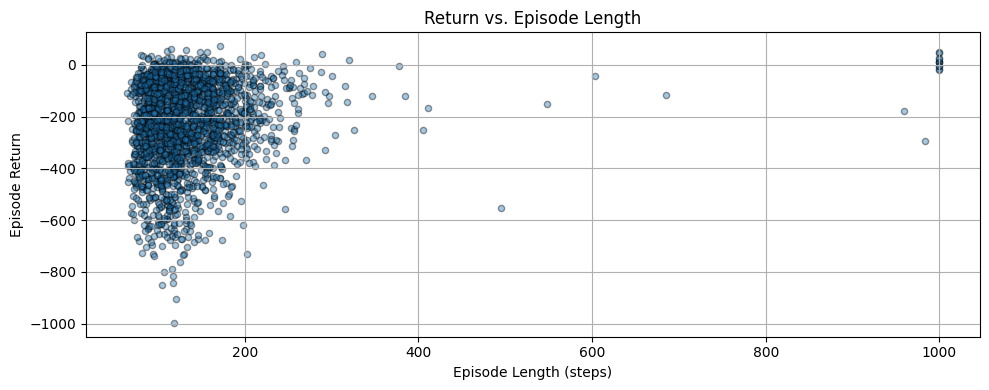

In [335]:
def plot_return_vs_episode_length(step_log, reward_history, save_path="return_vs_episode_length.png"):
    episode_lengths = np.diff([0] + step_log)

    plt.figure(figsize=(10, 4))
    plt.scatter(episode_lengths, reward_history, alpha=0.4, edgecolors='k', s=20)
    plt.xlabel("Episode Length (steps)")
    plt.ylabel("Episode Return")
    plt.title("Return vs. Episode Length")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_return_vs_episode_length(step_log, reward_history, save_path="ppo_lunarlander_return_vs_episode_length.png")

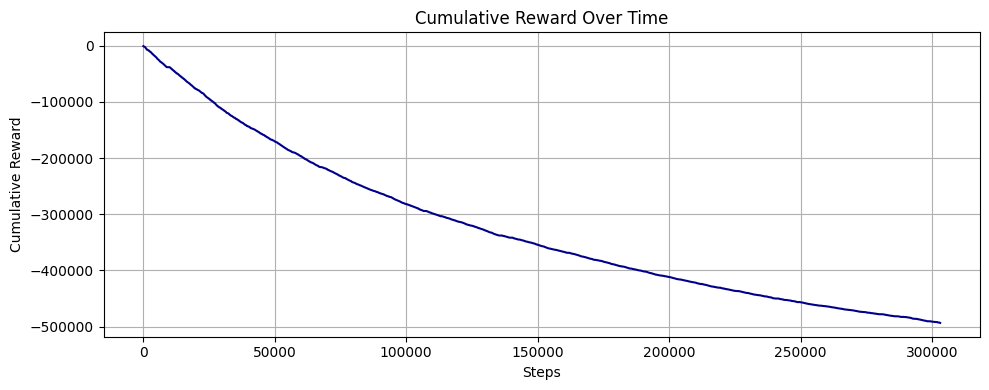

In [336]:
def plot_cumulative_reward(reward_history, step_log, save_path="cumulative_reward.png"):
    if len(reward_history) != len(step_log):
        print("Mismatch in reward and step logs.")
        return

    cumulative_reward = np.cumsum(reward_history)

    plt.figure(figsize=(10, 4))
    plt.plot(step_log, cumulative_reward, label="Cumulative Reward", color='darkblue')
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.title("Cumulative Reward Over Time")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_cumulative_reward(reward_history, step_log, save_path="ppo_lunarlander_cumulative_reward.png")

In [260]:
agent.evaluate(5)

C:\Users\elton\AppData\Local\Temp\ipykernel_136988\365955912.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action, _ = self.model.get_action(torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device))


Eval Episode 1: Total Reward = -91.5
Eval Episode 2: Total Reward = -151.9
Eval Episode 3: Total Reward = -14.4
Eval Episode 4: Total Reward = -2.9
Eval Episode 5: Total Reward = -73.4


SAC

In [261]:
obs_dim = ENV.observation_space.shape[0]
state_dim  = ENV.observation_space.shape[0]
action_dim = ENV.action_space.shape[0]
max_action = ENV.action_space.high[0]
act_limit = float(ENV.action_space.high[0])

In [262]:
state_dim

8

In [263]:
action_dim

2

In [264]:
# Actor network: outputs mean and log_std for squashed Gaussian policy
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU()
        )
        self.mean = nn.Linear(256, action_dim)
        self.log_std = nn.Linear(256, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = self.fc(state)
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = log_std.exp()
        return mean, std

    def sample(self, state):
        mean, std = self(state)
        dist = torch.distributions.Normal(mean, std)
        z = dist.rsample()
        action = torch.tanh(z)
        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(1, keepdim=True)
        return action * self.max_action, log_prob.sum(1, keepdim=True)


In [265]:
# Critic network: Q-value estimation
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        return self.q1(x), self.q2(x)

In [266]:
# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=int(1e6)):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

In [267]:
def _init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
        nn.init.constant_(m.bias, 0)

In [291]:
# SAC Agent
class SACAgent:
    def __init__(self, env):
        self.env = env
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.gamma = 0.99
        self.tau = 0.005
        self.batch_size = 256
        self.lr = 1e-4
        self.target_entropy = -env.action_space.shape[0]
        s_dim = env.observation_space.shape[0]
        a_dim = env.action_space.shape[0]
        self.max_action = float(env.action_space.high[0])
        self.step_rewards = []

        self.actor = Actor(s_dim, a_dim, self.max_action).to(self.device)
        self.critic = Critic(s_dim, a_dim).to(self.device)
        self.critic_target = Critic(s_dim, a_dim).to(self.device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.log_alpha = torch.tensor(np.log(0.2), requires_grad=True, device=self.device)
        self.actor_optim = Adam(self.actor.parameters(), lr=self.lr)
        self.critic_optim = Adam(self.critic.parameters(), lr=self.lr)
        self.alpha_optim = Adam([self.log_alpha], lr=self.lr)

        self.replay = ReplayBuffer()

        self.actor.apply(_init_weights)
        self.critic.apply(_init_weights)
        self.critic_target.apply(_init_weights)

    def update(self):

        alpha = self.log_alpha.exp().detach()
        
        if len(self.replay) < self.batch_size:
            return

        state, action, reward, next_state, done = self.replay.sample(self.batch_size)

        state = state.to(self.device)
        action = action.to(self.device)
        reward = reward.to(self.device)
        next_state = next_state.to(self.device)
        done = done.to(self.device)

        with torch.no_grad():
            next_action, next_log_prob = self.actor.sample(next_state)
            q1_next, q2_next = self.critic_target(next_state, next_action)
            q_target = reward + (1 - done) * self.gamma * (
                torch.min(q1_next, q2_next) - alpha * next_log_prob
            )

        q1, q2 = self.critic(state, action)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)

        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        new_action, log_prob = self.actor.sample(state)
        q1_pi, q2_pi = self.critic(state, new_action)
        alpha = self.log_alpha.exp().detach()
        actor_loss = (alpha * log_prob - torch.min(q1_pi, q2_pi)).mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_optim.step()

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_optim.zero_grad()
        alpha_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.alpha_optim.step()
        self.alpha = self.log_alpha.exp()

        # Soft update
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
                target_param.data.mul_(1.0 - self.tau)
                target_param.data.add_(self.tau * param.data)

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action, _ = self.actor.sample(state)
        return action.detach().cpu().numpy()[0]

    def train(self, total_steps=200000, start_steps=10000):
        state, _ = self.env.reset(seed=42)
        step_log = [] 
        reward_history = []
        episode_reward = 0


        for step in range(total_steps):
            if step < start_steps:
                action = self.env.action_space.sample()
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                    action, _ = self.actor.sample(state_tensor)
                    action = action.cpu().numpy()[0]

            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            self.step_rewards.append(reward) 
            clipped_reward = np.clip(reward, -1, 1)
            self.replay.push(state, action, clipped_reward, next_state, float(done))

            state = next_state
            episode_reward += reward

            if done:
                reward_history.append(episode_reward)
                step_log.append(step + 1)
                state, _ = self.env.reset()
                episode_reward = 0

            self.update()

            if (step + 1) % 1000 == 0:
                avg_reward = np.mean(reward_history[-100:]) if len(reward_history) >= 100 else np.mean(reward_history)
                print(f"Step {step + 1}, Avg Reward (last 100): {avg_reward:.2f}")

        return reward_history, step_log
    
    def plot_rewards(self, reward_history, step_log):
        plt.figure(figsize=(10, 5))
        plt.plot(step_log, reward_history, alpha=0.3, label="Raw reward")

        if len(reward_history) >= 100:
            smoothed = np.convolve(reward_history, np.ones(100) / 100, mode='valid')
            plt.plot(step_log[99:], smoothed, label="100-ep moving avg", color='red')

        plt.axhline(200, linestyle="--", color="green", label="Solved")
        plt.xlabel("Steps")
        plt.ylabel("Total Reward")
        plt.title("SAC on LunarLander-v3")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("sac_lunarlander_final.png")
        plt.show()

        # === Rolling Std Dev (last 50,000 steps only) ===
        if len(reward_history) >= 100:
            window = 100  # window size for std dev
            recent_indices = [i for i, s in enumerate(step_log) if s >= step_log[-1] - 50000]

            rolling_std = [
                np.std(reward_history[i - window:i])
                for i in recent_indices if i >= window
            ]

            recent_steps = [step_log[i] for i in recent_indices if i >= window]

            plt.figure(figsize=(10, 4))
            plt.plot(recent_steps, rolling_std)
            plt.xlabel("Steps")
            plt.ylabel("Std Dev")
            plt.title("Rolling Std Dev of Reward (Window = 100, Last 50,000 Steps)")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("sac_lunarlander_stddev.png")
            plt.show()

In [269]:
obs, _ = ENV.reset(seed=SEED)
episode_reward = 0
all_rewards = []

In [293]:
sac_agent = SACAgent(ENV)

In [ ]:
rewards, step_log = sac_agent.train(total_steps=300000, start_steps=10000)

Step 1000, Avg Reward (last 100): -398.68
Step 2000, Avg Reward (last 100): -372.10
Step 3000, Avg Reward (last 100): -366.66
Step 4000, Avg Reward (last 100): -377.10
Step 5000, Avg Reward (last 100): -375.40
Step 6000, Avg Reward (last 100): -370.59
Step 7000, Avg Reward (last 100): -361.61
Step 8000, Avg Reward (last 100): -372.58
Step 9000, Avg Reward (last 100): -367.95
Step 10000, Avg Reward (last 100): -366.40
Step 11000, Avg Reward (last 100): -347.59
Step 12000, Avg Reward (last 100): -334.68
Step 13000, Avg Reward (last 100): -330.06
Step 14000, Avg Reward (last 100): -320.48
Step 15000, Avg Reward (last 100): -318.46
Step 16000, Avg Reward (last 100): -313.39
Step 17000, Avg Reward (last 100): -309.53
Step 18000, Avg Reward (last 100): -298.38
Step 19000, Avg Reward (last 100): -279.82
Step 20000, Avg Reward (last 100): -268.51
Step 21000, Avg Reward (last 100): -267.69
Step 22000, Avg Reward (last 100): -256.46
Step 23000, Avg Reward (last 100): -243.23
Step 24000, Avg Rewa

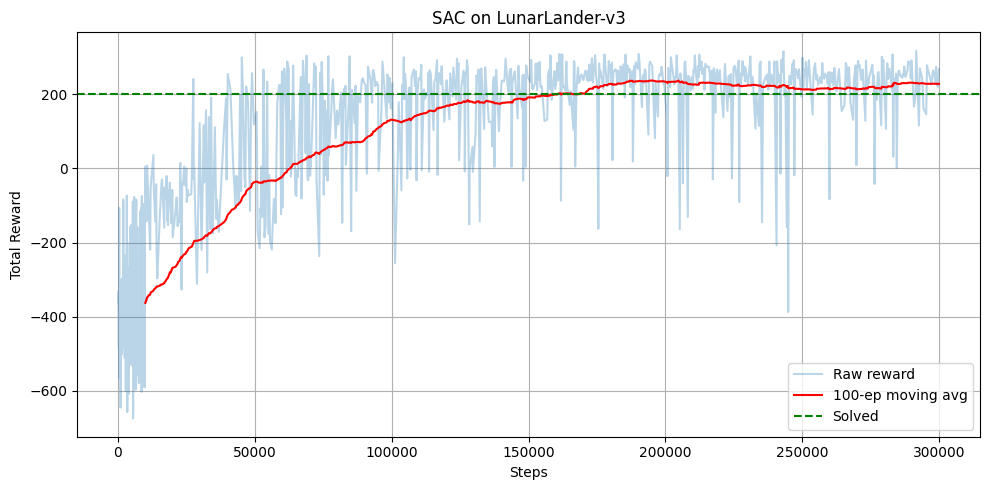

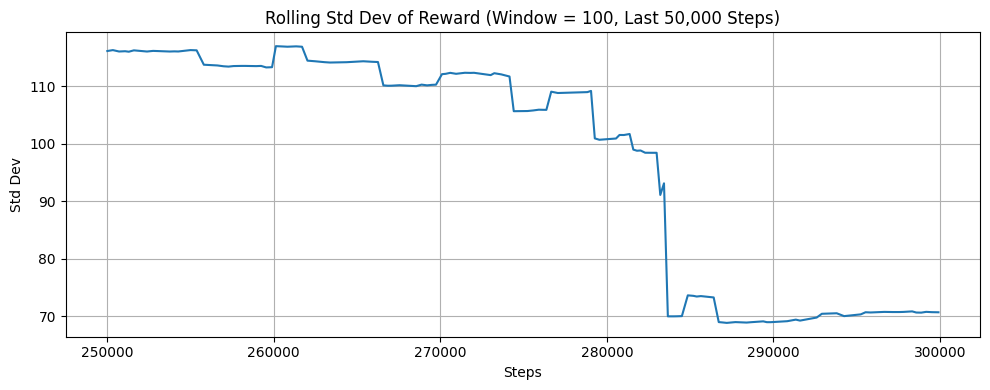

In [294]:
sac_agent.plot_rewards(rewards, step_log)

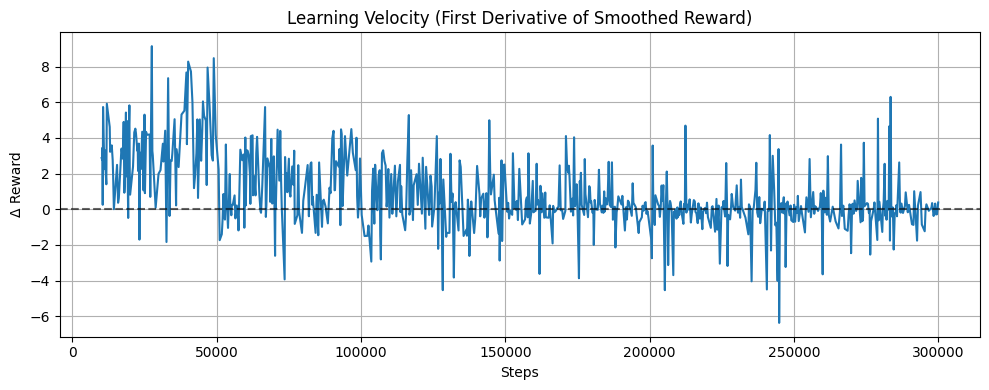

In [297]:
def plot_learning_velocity(step_log, reward_history, window=100):
    smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')
    velocity = np.diff(smoothed)

    plt.figure(figsize=(10, 4))
    plt.plot(step_log[window:window+len(velocity)], velocity)
    plt.axhline(0, linestyle='--', color='black', alpha=0.6)
    plt.title("Learning Velocity (First Derivative of Smoothed Reward)")
    plt.xlabel("Steps")
    plt.ylabel("Δ Reward")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_learning_velocity(step_log, rewards, window=100)

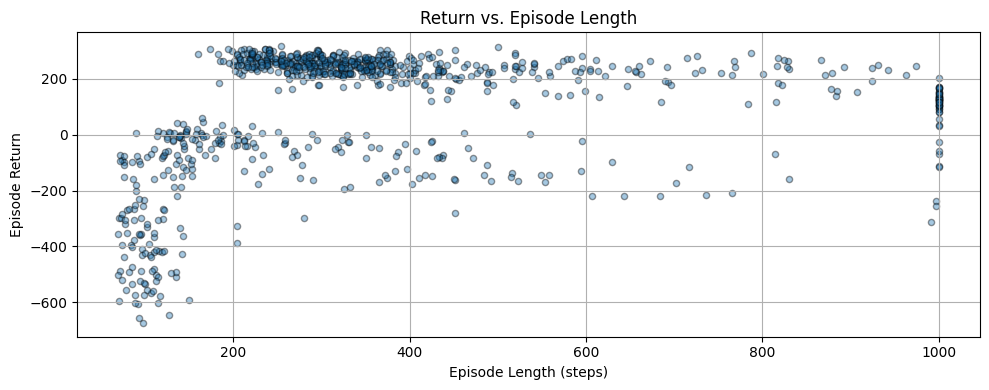

In [313]:
plot_return_vs_episode_length(step_log, rewards, save_path="sac_lunarlander_return_vs_episode_length.png")

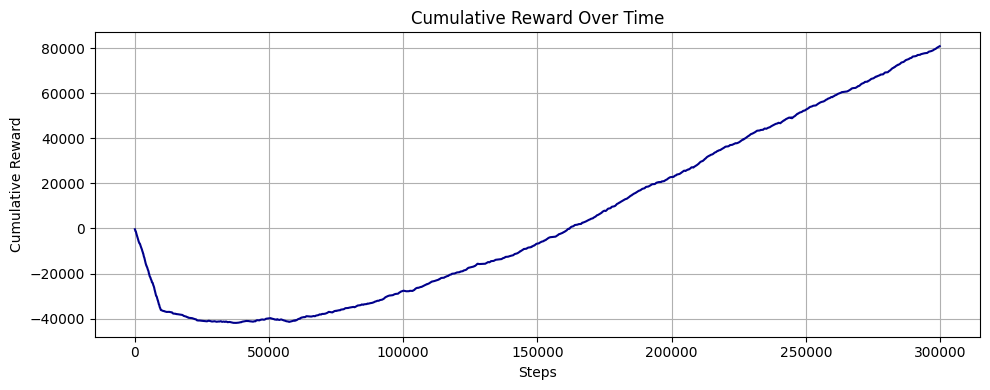

In [319]:
plot_cumulative_reward(rewards, step_log, save_path="sac_lunarlander_cumulative_reward.png")

In [272]:
def evaluate_sac(model, episodes=5):
    test_env = gym.make("LunarLander-v3", continuous=True, render_mode="human")
    for ep in range(episodes):
        obs, _ = test_env.reset()
        total_reward = 0
        for _ in range(1000):
            with torch.no_grad():
                action = model.get_action(obs)
            obs, r, term, trunc, _ = test_env.step(action)
            total_reward += r
            if term or trunc:
                break
        print(f"Eval Episode {ep+1}: Total Reward = {total_reward:.1f}")
    test_env.close()


In [273]:
evaluate_sac(sac_agent)

Eval Episode 1: Total Reward = 227.2
Eval Episode 2: Total Reward = 284.4
Eval Episode 3: Total Reward = 247.6
Eval Episode 4: Total Reward = 296.9
Eval Episode 5: Total Reward = 271.8
